# Standard School Data Analytics — Teacher & Student Enrolment

**Project type:** Exploratory Data Analysis (EDA) + Education Workforce Analytics  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter

## Business objective

This project combines two school-level datasets:

1. **Teacher dataset** — teacher/staff characteristics, qualifications, appointment type, training, gender and school assignment.
2. **Enrolment dataset** — class-wise student enrolment from pre-primary through Class 12.

The goal is to answer practical questions such as:

- How many teachers and students are covered?
- Which schools have the highest and lowest student–teacher ratios?
- Which schools may have potential staffing pressure?
- How is teacher workforce distributed by gender, qualification and appointment type?
- Which classes have the highest enrolment?
- Are there schools with students but no teacher records, or teacher records but no enrolment?
- What data-quality issues should be addressed before operational use?

> **Privacy note:** The teacher file contains personally identifiable or potentially sensitive fields. Do **not** publish the raw teacher CSV to a public GitHub repository. Keep it local/private, or publish only an anonymized/aggregated dataset.


In [1]:
# 1. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
TEACHER_FILE = DATA_DIR / "all_teachers_2026.csv"
ENROL_FILE = DATA_DIR / "enrolment_2026.csv"

teachers = pd.read_csv(TEACHER_FILE)
enrol = pd.read_csv(ENROL_FILE)

print("Teacher data:", teachers.shape)
print("Enrolment data:", enrol.shape)


Teacher data: (614, 56)
Enrolment data: (138, 73)


## 2. Initial data audit

In [2]:
# Structure and missingness
display(teachers.head())
display(enrol.head())

audit = pd.DataFrame({
    "teachers_dtype": teachers.dtypes.astype(str),
    "teachers_missing": teachers.isna().sum(),
    "teachers_missing_pct": (teachers.isna().mean() * 100).round(1)
})
display(audit.sort_values("teachers_missing_pct", ascending=False).head(20))

enrol_audit = pd.DataFrame({
    "dtype": enrol.dtypes.astype(str),
    "missing": enrol.isna().sum(),
    "missing_pct": (enrol.isna().mean() * 100).round(1)
})
display(enrol_audit.sort_values("missing_pct", ascending=False).head(20))


,UDISE_Code,School_Name,District_Name_&_Code,Block_Name_&_Code,School_Management_Code,School_Category_Code,School_Type_Code,Teaching_Staff_Name,Teaching_Staff_Code,Gender,DOB,Age_In_Years,Social_Category,Academic_Qualification,Trade,Professional_Qualification,Maths_Studied_Upto,Science_Studied_Upto,English_Studied_Upto,Social_Study_Upto,Lang_Studied_Upto,Disab_Type,Nature_Of_Appointment,Type_of_Teacher,Doj_Service,Yoj_Present_School,Date_of_Current_Post_Held,Class_Taught,Appointed_For_Level,Appt_For_Subject,Sub_Taught_1,Sub_Taught_2,Teacher_Deputation,Teacher_School_Guest_Contractual,Trained_Cwsn,Trained_Comp,Training_Recieved,Training_Needed,Training_NISHTHA,Non_Teach_Days,Language_1,Language_2,Language_3,Trained_SSA_YN,Cyber_Safety_YN,Psy_Soc_Aspect_YN,Rec_Training_Support_CWSN_YN,Ctet_Qualified,Ctet_Qualified_Year,Mobile_No,Aadhaar_Name,AADHAAR_Verified,National_Code,Completion_Status,Hos_Yn,Ahos_Yn
0,19260208903,MRITUNJAY RAY SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),5 - Private Unaided(Recognized),6 - Pr. Up Pr. and Secondary Only,3-Co-educational,CHAITALI BAURI,676047,2-Female,**/**/1983,43,2-SC,4-Graduate,2-B.Sc.,2 - Bachelor of Elementary Education (B.El.Ed.),2-Secondary,2-Secondary,4-Graduate,4-Graduate,4-Graduate,1-Not applicable,1 - Regular,3 - Teacher,01/12/2015,01/12/2015,NaN,1-Primary only,NaN,1-All Subjects,1-All Subjects,1-All Subjects,2-No,2-No,2-No,1-Yes,8 - Not Required,8 - Not Required,NaN,15,19 - English,02 - Bengali,04 - Hindi,2-No,NaN,NaN,2-No,NaN,0,82******08,CHAITALI BAURI,Verification Under Process,TP86763841,Not Completed,2-No,2-No
1,19260208903,MRITUNJAY RAY SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),5 - Private Unaided(Recognized),6 - Pr. Up Pr. and Secondary Only,3-Co-educational,MANOSHI ROY,560346,2-Female,**/**/1985,41,1-General,5-Post Graduate,1-NOT APPLICABLE,3 - B.Ed. or equivalent,1-Below Secondary,2-Secondary,2-Secondary,2-Secondary,2-Secondary,1-Not applicable,1 - Regular,3 - Teacher,01/08/2017,01/08/2017,NaN,11-Pre-Primary & Primary,NaN,1-All Subjects,1-All Subjects,1-All Subjects,2-No,2-No,2-No,1-Yes,8 - Not Required,8 - Not Required,NaN,15,19 - English,02 - Bengali,04 - Hindi,2-No,NaN,NaN,2-No,NaN,0,99******84,MANOSHI ROY,Verification Under Process,TP86763948,Not Completed,2-No,2-No
2,19260208903,MRITUNJAY RAY SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),5 - Private Unaided(Recognized),6 - Pr. Up Pr. and Secondary Only,3-Co-educational,KIRAN MAJI,793611,2-Female,**/**/1999,27,2-SC,4-Graduate,2-B.Sc.,2 - Bachelor of Elementary Education (B.El.Ed.),2-Secondary,2-Secondary,4-Graduate,4-Graduate,4-Graduate,1-Not applicable,1 - Regular,3 - Teacher,02/01/2023,17/01/2023,NaN,2-Upper primary only,NaN,46-English,46-English,46-English,2-No,2-No,2-No,1-Yes,8 - Not Required,8 - Not Required,NaN,156,19 - English,04 - Hindi,02 - Bengali,2-No,NaN,NaN,2-No,NaN,0,82******35,KIRAN MAJI,Verification Under Process,TP86763850,Not Completed,2-No,2-No
3,19260208903,MRITUNJAY RAY SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),5 - Private Unaided(Recognized),6 - Pr. Up Pr. and Secondary Only,3-Co-educational,ABIRLAL ROY,675513,1-Male,**/**/1992,34,1-General,4-Graduate,2-B.Sc.,3 - B.Ed. or equivalent,3-Higher Secondary,4-Graduate,4-Graduate,2-Secondary,4-Graduate,1-Not applicable,1 - Regular,3 - Teacher,20/01/2021,20/01/2021,NaN,3-Primary and Upper primary,NaN,1-All Subjects,1-All Subjects,1-All Subjects,2-No,2-No,2-No,1-Yes,8 - Not Required,8 - Not Required,NaN,15,19 - English,02 - Bengali,04 - Hindi,2-No,NaN,NaN,2-No,NaN,0,97******80,ABIRLAL ROY,Verification Under Process,TP86756799,Not Completed,2-No,2-No
4,19260208903,MRITUNJAY RAY SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),5 - Private Unaided(Recognized),6 - Pr. Up Pr. and Secondary Only,3-Co-educational,ADESH SINGH,793613,1-Male,**/**/2002,24,1-General,4-Graduate,4-BBA,2 - Bachelor of Elementary Education (B.El.Ed.),1-Below Secondary,2-Secondary,4-Graduate,4-Graduate,4-Graduate,1-No

,District Name,District Code,Block Name,Block Code,Cluster Code,School Name,UDISE Code,School Management,School Category,PP3(Boys),PP3(Girls),PP3(Trans),PP3(Total),PP2(Boys),PP2(Girls),PP2(Trans),PP2(Total),PP1(Boys),PP1(Girls),PP1(Trans),PP1(Total),Class 1(Boys),Class 1(Girls),Class 1(Trans),Class 1(Total),Class 2(Boys),Class 2(Girls),Class 2(Trans),Class 2(Total),Class 3(Boys),Class 3(Girls),Class 3(Trans),Class 3(Total),Class 4(Boys),Class 4(Girls),Class 4(Trans),Class 4(Total),Class 5(Boys),Class 5(Girls),Class 5(Trans),Class 5(Total),Class 6(Boys),Class 6(Girls),Class 6(Trans),Class 6(Total),Class 7(Boys),Class 7(Girls),Class 7(Trans),Class 7(Total),Class 8(Boys),Class 8(Girls),Class 8(Trans),Class 8(Total),Class 9(Boys),Class 9(Girls),Class 9(Trans),Class 9(Total),Class 10(Boys),Class 10(Girls),Class 10(Trans),Class 10(Total),Class 11(Boys),Class 11(Girls),Class 11(Trans),Class 11(Total),Class 12(Boys),Class 12(Girls),Class 12(Trans),Class 12(Total),Total Boys,Total Girls,Total Trans,Grand Total
0,PASCHIM BARDHAMAN,1926,BARABANI,192602,CLU1922530,ALIGANJ F.P. SCHOOL,19260204902,1,1,0,0,0,0,0,0,0,0,10,9,0,19,9,8,0,17,13,8,0,21,19,7,0,26,10,9,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61,41,0,102
1,PASCHIM BARDHAMAN,1926,BARABANI,192602,CLU1922531,ALIPUR F.P. SCHOOL,19260207402,1,1,0,0,0,0,0,0,0,0,6,5,0,11,13,4,0,17,2,12,0,14,5,4,0,9,6,5,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,30,0,62
2,PASCHIM BARDHAMAN,1926,BARABANI,192602,CLU1922531,AMDIHA F.P. SCHOOL,19260208004,1,1,0,0,0,0,0,0,0,0,1,0,0,1,6,5,0,11,8,8,0,16,10,7,0,17,5,4,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,24,0,54
3,PASCHIM BARDHAMAN,1926,BARABANI,192602,CLU1922531,AMDIHA HINDI F.P. SCHOOL,19260208005,1,1,0,0,0,0,0,0,0,0,2,1,0,3,0,4,0,4,1,0,0,1,5,4,0,9,6,2,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,11,0,25
4,PASCHIM BARDHAMAN,1926,BARABANI,192602,CLU1922531,AMNALA F.P. SCHOOL,19260207805,1,1,0,0,0,0,0,0,0,0,8,7,0,15,9,4,0,13,5,7,0,12,9,7,0,16,11,9,0,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,42,34,0,76


,teachers_dtype,teachers_missing,teachers_missing_pct
Language_3,str,421,68.6
Appointed_For_Level,str,362,59.0
Training_NISHTHA,str,187,30.5
Cyber_Safety_YN,str,187,30.5
Psy_Soc_Aspect_YN,str,187,30.5
Date_of_Current_Post_Held,str,171,27.9
Ctet_Qualified,str,170,27.7
Trade,str,116,18.9
Sub_Taught_2,str,106,17.3
National_Code,str,31,5.0


,dtype,missing,missing_pct
District Name,str,0,0.0
District Code,int64,0,0.0
Block Name,str,0,0.0
Block Code,int64,0,0.0
Cluster Code,str,0,0.0
School Name,str,0,0.0
UDISE Code,int64,0,0.0
School Management,int64,0,0.0
School Category,int64,0,0.0
PP3(Boys),int64,0,0.0


## 3. Create an analysis-ready school key

The common identifier is **UDISE Code**. We normalize it to text before joining so that leading/trailing formatting differences do not create false mismatches.

In [3]:
teachers["UDISE_Key"] = teachers["UDISE_Code"].astype("string").str.strip()
enrol["UDISE_Key"] = enrol["UDISE Code"].astype("string").str.strip()

# --- School category ---------------------------------------------------------
# Prefer an explicit school-category field if one exists in either source.
category_candidates = [
    "School_Category", "School Category", "School_Category_Name",
    "School Type", "School_Type", "School Level", "School_Level",
    "Category", "Category_Name", "School Management Category"
]

teacher_category_col = next((c for c in category_candidates if c in teachers.columns), None)
enrol_category_col = next((c for c in category_candidates if c in enrol.columns), None)

# If no explicit category is available, infer a broad category from the
# classes that have enrolment. This is a derived analytical category,
# not an official school classification.
def infer_school_category(row):
    class_groups = {
        "Primary": ["PP3(Total)", "PP2(Total)", "PP1(Total)",
                    "Class 1(Total)", "Class 2(Total)", "Class 3(Total)",
                    "Class 4(Total)", "Class 5(Total)"],
        "UP": ["Class 6(Total)", "Class 7(Total)", "Class 8(Total)"],
        "High": ["Class 9(Total)", "Class 10(Total)"],
        "Higher Secondary": ["Class 11(Total)", "Class 12(Total)"]
    }

    active = []
    for category, cols in class_groups.items():
        existing = [c for c in cols if c in row.index]
        if existing and pd.to_numeric(row[existing], errors="coerce").fillna(0).sum() > 0:
            active.append(category)

    if not active:
        return "Unknown"
    if len(active) == 1:
        return active[0]
    return " + ".join(active)

# School-level teacher count and teacher-name list.
teacher_agg = {
    "teacher_records": ("Teaching_Staff_Name", "size"),
    "unique_staff_codes": ("Teaching_Staff_Code", "nunique"),
    "school_name_teacher": ("School_Name", "first"),
    "district": ("District_Name_&_Code", "first"),
    "block": ("Block_Name_&_Code", "first")
}

if teacher_category_col:
    teacher_agg["school_category_teacher"] = (teacher_category_col, "first")

school_teacher = (
    teachers.groupby("UDISE_Key", dropna=False)
    .agg(**teacher_agg)
    .reset_index()
)

# Keep every non-missing teacher name, in a readable school-level list.
teacher_names = (
    teachers.assign(
        _teacher_name=teachers["Teaching_Staff_Name"]
        .fillna("")
        .astype(str)
        .str.strip()
    )
    .groupby("UDISE_Key")["_teacher_name"]
    .apply(lambda s: "; ".join(dict.fromkeys([x for x in s if x])))
    .rename("teacher_names")
    .reset_index()
)

school_teacher = school_teacher.merge(teacher_names, on="UDISE_Key", how="left")

# School-level enrolment information.
school_enrol_cols = [
    "UDISE_Key", "School Name", "District Name", "Block Name",
    "Grand Total", "Total Boys", "Total Girls", "Total Trans"
]
if enrol_category_col:
    school_enrol_cols.append(enrol_category_col)

school_enrol = enrol[school_enrol_cols].copy()

# If an explicit category exists, retain it; otherwise infer it from class totals.
if enrol_category_col:
    school_enrol["school_category"] = (
        school_enrol[enrol_category_col].fillna("Unknown").astype(str).str.strip()
    )
else:
    school_enrol["school_category"] = enrol.apply(infer_school_category, axis=1).values

school = school_enrol.merge(
    school_teacher,
    on="UDISE_Key",
    how="outer",
    indicator=True,
    suffixes=("", "_teacher")
)

# Resolve category from teacher data where enrolment category is unavailable.
if teacher_category_col:
    mask = school["school_category"].isin(["", "Unknown", "nan", "None"])
    school.loc[mask, "school_category"] = (
        school.loc[mask, "school_category_teacher"].fillna("Unknown").astype(str)
    )

school["school_category"] = school["school_category"].fillna("Unknown").astype(str).str.strip()
school["teacher_records"] = school["teacher_records"].fillna(0).astype(int)
school["unique_staff_codes"] = school["unique_staff_codes"].fillna(0).astype(int)
school["teacher_names"] = school["teacher_names"].fillna("")
school["Grand Total"] = school["Grand Total"].fillna(0)

school["student_teacher_ratio"] = np.where(
    school["teacher_records"] > 0,
    school["Grand Total"] / school["teacher_records"],
    np.nan
)

school["teacher_student_ratio"] = np.where(
    school["Grand Total"] > 0,
    school["teacher_records"] / school["Grand Total"],
    np.nan
)

display(school.head())
print("School category source:",
      enrol_category_col or teacher_category_col or "Derived from active class enrolment")
print("Schools in enrolment:", enrol["UDISE_Key"].nunique())
print("Schools in teacher data:", teachers["UDISE_Key"].nunique())
print("Schools in both:", (school["_merge"] == "both").sum())


,UDISE_Key,School Name,District Name,Block Name,Grand Total,Total Boys,Total Girls,Total Trans,School Category,school_category,teacher_records,unique_staff_codes,school_name_teacher,district,block,teacher_names,_merge,student_teacher_ratio,teacher_student_ratio
0,19260200101,BARABANI F.P. SCHOOL,PASCHIM BARDHAMAN,BARABANI,89,47,42,0,1,1,4,4,BARABANI F.P. SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),KALYAN GORAI; SABYASACHI DAS; HIMITA BANERJEE ...,both,22.25,0.044944
1,19260200102,JOYRAMDANGA F.P. SCHOOL,PASCHIM BARDHAMAN,BARABANI,129,62,67,0,1,1,5,5,JOYRAMDANGA F.P. SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),TANUMOY MAJI; SHIB SHANKAR KARFA; SHANTI GHOSH...,both,25.80,0.038760
2,19260200103,BARABANI ADI SSK,PASCHIM BARDHAMAN,BARABANI,26,8,18,0,1,1,1,1,BARABANI ADI SSK,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),KHASHMA PAUL,both,26.00,0.038462
3,19260200104,JOYRAMDANGA JR. HIGH SCHOOL,PASCHIM BARDHAMAN,BARABANI,102,58,44,0,4,4,1,1,JOYRAMDANGA JR. HIGH SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),BIDYUT CHATTARAJ,both,102.00,0.009804
4,19260200201,BARABANI STATION F.P. SCHOOL,PASCHIM BARDHAMAN,BARABANI,111,56,55,0,1,1,5,5,BARABANI STATION F.P. SCHOOL,PASCHIM BARDHAMAN (1926),BARABANI (192602) (192602),MAHUA GHOSH DUTTA; RIMPA SADHU; DEBPARNA CHATT...,both,22.20,0.045045


School category source: School Category
Schools in enrolment: 138
Schools in teacher data: 136
Schools in both: 136


## 4A. Analysis-ready school category & teacher directory

This section creates two practical school-level reports:

1. **School category-wise summary** — schools, students, teacher records and average students per teacher for Primary, UP, High, Higher Secondary and any combined categories present in the data.
2. **School-wise teacher directory** — one row per school with teacher count and all available teacher names beside the count.

The category is taken from an explicit category field when available. If neither source contains one, it is **derived from active class enrolment** and should be treated as an analytical classification, not an official school category.

,school_category,schools,students,teacher_records,schools_with_teachers,students_per_teacher
3,5,7,9946,161,7,61.776398
0,1,113,8261,335,113,24.659701
5,7,5,1811,51,5,35.509804
2,4,9,774,25,7,30.960000
4,6,1,240,16,1,15.000000
1,2,3,63,26,3,2.423077


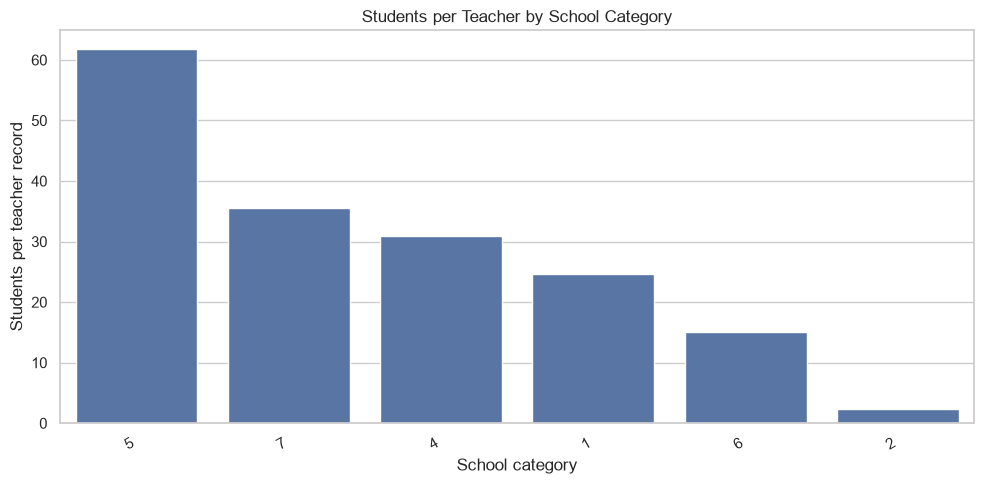

In [4]:
# Category-wise school summary
category_summary = (
    school.groupby("school_category", dropna=False)
    .agg(
        schools=("UDISE_Key", "nunique"),
        students=("Grand Total", "sum"),
        teacher_records=("teacher_records", "sum"),
        schools_with_teachers=("teacher_records", lambda s: int((s > 0).sum()))
    )
    .reset_index()
)

category_summary["students_per_teacher"] = np.where(
    category_summary["teacher_records"] > 0,
    category_summary["students"] / category_summary["teacher_records"],
    np.nan
)

category_summary = category_summary.sort_values(
    ["students", "school_category"], ascending=[False, True]
)

display(category_summary)

# Optional visual summary
plot_data = category_summary.sort_values("students_per_teacher", ascending=False).copy()
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="school_category", y="students_per_teacher")
plt.title("Students per Teacher by School Category")
plt.xlabel("School category")
plt.ylabel("Students per teacher record")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [5]:
# School-wise teacher directory
school_teacher_directory = school[[
    "UDISE_Key", "School Name", "school_category",
    "District Name", "Block Name",
    "teacher_records", "unique_staff_codes", "teacher_names",
    "Grand Total", "student_teacher_ratio"
]].copy()

school_teacher_directory = school_teacher_directory.sort_values(
    ["school_category", "School Name"], na_position="last"
)

display(
    school_teacher_directory[
        ["UDISE_Key", "School Name", "school_category",
         "teacher_records", "teacher_names", "Grand Total",
         "student_teacher_ratio"]
    ].head(50)
)


,UDISE_Key,School Name,school_category,teacher_records,teacher_names,Grand Total,student_teacher_ratio
69,19260204902,ALIGANJ F.P. SCHOOL,1,4,RAJKUMAR MONDAL; SEKHAR KANTI BASU; KAMALAKANT...,102,25.500000
107,19260207402,ALIPUR F.P. SCHOOL,1,3,BISWAJIT PAUL; SHIBU BOURI; ABIR CHATTERJEE,62,20.666667
116,19260208004,AMDIHA F.P. SCHOOL,1,3,DULAL CHANDRA MANDAL; DIPESH CHATTOPADHYAY; SN...,54,18.000000
117,19260208005,AMDIHA HINDI F.P. SCHOOL,1,2,JORAWAR SINGH; SANDIP KUMAR BISHWAKARMA,25,12.500000
113,19260207805,AMNALA F.P. SCHOOL,1,3,SOHINI MONDAL; PARTHANKAR PRAMANIK; SANTU DEY,76,25.333333
29,19260202104,AMULIA SSK,1,1,IRA KARMAKAR,32,32.000000
135,19260208904,ANANDA MARGA PRIMARY SCHOOL,1,7,JHARNA KARMAKAR; SIPRA BOSE; SANJUKTA PAIK; SH...,103,14.714286
122,19260208302,ASANBANI ADIBASI F.P. SCHOOL,1,3,MADHUMITA MISHRA; KRISHNA KISKU; BIDESH CHANDR...,69,23.000000
119,19260208103,BALIAPUR F.P. SCHOOL,1,5,GOUTAM DEY; RUPASREE LAHIRI; DOLI MANDAL; SUSM...,129,25.800000
118,19260208101,BALIAPUR NICHUPARA F.P. SCHOOL,1,2,BABLU SENGUPTA; KALIPADA CHATTERJEE,25,12.500000


### School-category reports

The following tables are the main reporting outputs for the project. The first is useful for management-level comparison; the second is useful for school-level staffing review.

In [7]:
# Report 1: category-wise school report
category_report = category_summary[[
    "school_category", "schools", "students",
    "teacher_records", "schools_with_teachers",
    "students_per_teacher"
]].copy()

display(category_report)

# Report 2: school-wise teacher report
school_teacher_report = school_teacher_directory[[
    "UDISE_Key", "School Name", "school_category",
    "District Name", "Block Name",
    "teacher_records", "unique_staff_codes",
    "teacher_names", "Grand Total", "student_teacher_ratio"
]].copy()

display(school_teacher_report.head(50))


,school_category,schools,students,teacher_records,schools_with_teachers,students_per_teacher
3,5,7,9946,161,7,61.776398
0,1,113,8261,335,113,24.659701
5,7,5,1811,51,5,35.509804
2,4,9,774,25,7,30.960000
4,6,1,240,16,1,15.000000
1,2,3,63,26,3,2.423077


,UDISE_Key,School Name,school_category,District Name,Block Name,teacher_records,unique_staff_codes,teacher_names,Grand Total,student_teacher_ratio
69,19260204902,ALIGANJ F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,4,4,RAJKUMAR MONDAL; SEKHAR KANTI BASU; KAMALAKANT...,102,25.500000
107,19260207402,ALIPUR F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,3,3,BISWAJIT PAUL; SHIBU BOURI; ABIR CHATTERJEE,62,20.666667
116,19260208004,AMDIHA F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,3,3,DULAL CHANDRA MANDAL; DIPESH CHATTOPADHYAY; SN...,54,18.000000
117,19260208005,AMDIHA HINDI F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,2,2,JORAWAR SINGH; SANDIP KUMAR BISHWAKARMA,25,12.500000
113,19260207805,AMNALA F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,3,3,SOHINI MONDAL; PARTHANKAR PRAMANIK; SANTU DEY,76,25.333333
29,19260202104,AMULIA SSK,1,PASCHIM BARDHAMAN,BARABANI,1,1,IRA KARMAKAR,32,32.000000
135,19260208904,ANANDA MARGA PRIMARY SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,7,5,JHARNA KARMAKAR; SIPRA BOSE; SANJUKTA PAIK; SH...,103,14.714286
122,19260208302,ASANBANI ADIBASI F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,3,3,MADHUMITA MISHRA; KRISHNA KISKU; BIDESH CHANDR...,69,23.000000
119,19260208103,BALIAPUR F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,5,5,GOUTAM DEY; RUPASREE LAHIRI; DOLI MANDAL; SUSM...,129,25.800000
118,19260208101,BALIAPUR NICHUPARA F.P. SCHOOL,1,PASCHIM BARDHAMAN,BARABANI,2,2,BABLU SENGUPTA; KALIPADA CHATTERJEE,25,12.500000


## 5. Executive KPIs

In [8]:
kpis = pd.Series({
    "Schools with enrolment records": enrol["UDISE_Key"].nunique(),
    "Schools with teacher records": teachers["UDISE_Key"].nunique(),
    "Teacher/staff records": len(teachers),
    "Students": int(enrol["Grand Total"].sum()),
    "Female students": int(enrol["Total Girls"].sum()),
    "Male students": int(enrol["Total Boys"].sum()),
    "Transgender students": int(enrol["Total Trans"].sum()),
    "Teacher records with missing staff code": int(teachers["Teaching_Staff_Code"].isna().sum()),
    "Schools with zero enrolment": int((enrol["Grand Total"] == 0).sum())
})
display(kpis.to_frame("Value"))


,Value
Schools with enrolment records,138
Schools with teacher records,136
Teacher/staff records,614
Students,21095
Female students,10419
Male students,10675
Transgender students,1
Teacher records with missing staff code,30
Schools with zero enrolment,6


## 6. Student enrolment by class

,class,students
11,Class 9(Total),2821
12,Class 10(Total),2371
10,Class 8(Total),1830
9,Class 7(Total),1681
3,Class 1(Total),1648
6,Class 4(Total),1648
5,Class 3(Total),1590
4,Class 2(Total),1504
8,Class 6(Total),1420
14,Class 12(Total),1311


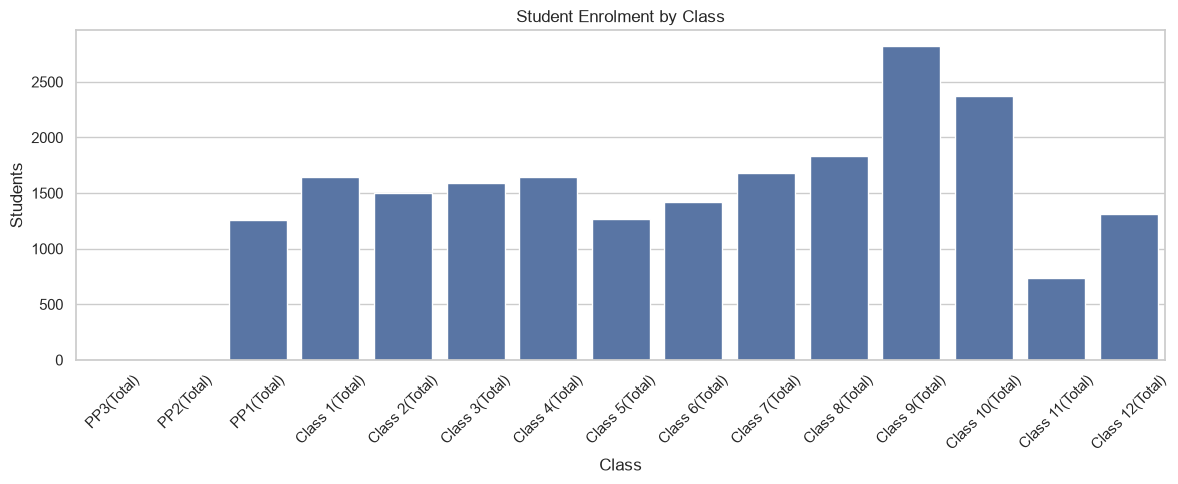

In [9]:
class_total_cols = [
    "PP3(Total)", "PP2(Total)", "PP1(Total)"
] + [f"Class {i}(Total)" for i in range(1, 13)]

class_enrolment = (
    enrol[class_total_cols]
    .sum()
    .rename("students")
    .reset_index()
    .rename(columns={"index": "class"})
)

display(class_enrolment.sort_values("students", ascending=False))

plt.figure(figsize=(12, 5))
sns.barplot(data=class_enrolment, x="class", y="students")
plt.title("Student Enrolment by Class")
plt.xlabel("Class")
plt.ylabel("Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Gender distribution

,students
Boys,10675
Girls,10419
Transgender,1


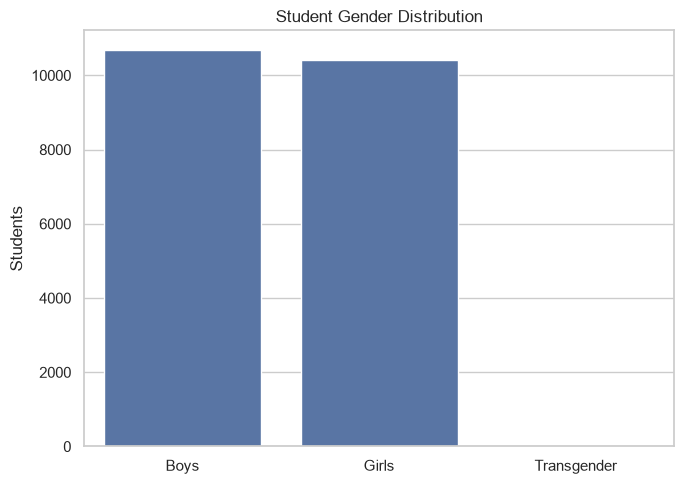

In [10]:
gender_totals = pd.Series({
    "Boys": enrol["Total Boys"].sum(),
    "Girls": enrol["Total Girls"].sum(),
    "Transgender": enrol["Total Trans"].sum()
})

display(gender_totals.to_frame("students"))

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_totals.index, y=gender_totals.values)
plt.title("Student Gender Distribution")
plt.ylabel("Students")
plt.xlabel("")
plt.tight_layout()
plt.show()


## 8. School-level student–teacher ratio (STR)

In [11]:
# Focus on schools that have both enrolment and teacher records.
str_table = school[
    (school["_merge"] == "both") &
    (school["Grand Total"] > 0) &
    (school["teacher_records"] > 0)
].copy()

# Rank schools by students per teacher.
top_str = str_table.sort_values("student_teacher_ratio", ascending=False)
low_str = str_table.sort_values("student_teacher_ratio", ascending=True)

display(top_str[[
    "School Name", "Grand Total", "teacher_records", "student_teacher_ratio"
]].head(15))

display(low_str[[
    "School Name", "Grand Total", "teacher_records", "student_teacher_ratio"
]].head(15))


,School Name,Grand Total,teacher_records,student_teacher_ratio
75,DASKEARI JUNIOR HIGH SCHOOL,216,2,108.000000
3,JOYRAMDANGA JR. HIGH SCHOOL,102,1,102.000000
79,PANURIA HATTALA SSK,98,1,98.000000
88,MADANPUR HIGH SCHOOL,520,7,74.285714
48,DOMOHANI KELEJORA GIRLS' HIGH SCHOOL,2115,29,72.931034
87,MADANPUR F.P. SCHOOL,349,5,69.800000
33,PANCHGACHIA M.V. VIDYAYATAN,966,15,64.400000
65,GOURANGDI R.K.S. INSTITUTION,2672,42,63.619048
39,DOMOHANI KELEJORA HIGH SCHOOL(H.S),1747,30,58.233333
18,JAMGRAM ANCHALIK HIGH SCHOOL (H.S.),1102,19,58.000000


,School Name,Grand Total,teacher_records,student_teacher_ratio
31,BLUE HEAVEN MONTESSORY SCHOOL,3,1,3.000000
137,TARAKESHWAR INTERNATIONAL SCHOOL,60,19,3.157895
85,GOURANDI PUBLIC SCHOOL,40,12,3.333333
66,VIVEKANANDA PUBLIC SCHOOL,32,8,4.000000
121,JANARDAN SAYER F.P. SCHOOL,10,2,5.000000
10,LAKHANDHAWRA SSK,14,2,7.000000
52,DOMOHANI BAZAR URDU F P SCHOOL,24,3,8.000000
59,RUNAKURA F.P. SCHOOL,17,2,8.500000
26,SHYAMAPUR ADIBASI F.P. SCHOOL,18,2,9.000000
81,PANURIA HATTOLA URDU F.P. SCHOL,31,3,10.333333


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(str_table["student_teacher_ratio"], bins=20, kde=True)
plt.axvline(str_table["student_teacher_ratio"].median(), linestyle="--",
            label=f"Median = {str_table['student_teacher_ratio'].median():.1f}")
plt.title("Distribution of Student–Teacher Ratio")
plt.xlabel("Students per teacher record")
plt.ylabel("Number of schools")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation guide

A high student–teacher ratio can indicate potential staffing pressure, but it is **not automatically proof of understaffing**. School level, class structure, teacher subject specialization, part-time/guest staff and timetable arrangements should be considered before taking action.

## 9. Teacher workforce profile

In [12]:
def clean_value_counts(df, col, top_n=15):
    return (
        df[col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .head(top_n)
        .rename_axis(col)
        .reset_index(name="count")
    )

print("Teacher gender")
display(clean_value_counts(teachers, "Gender"))

print("Appointment type")
display(clean_value_counts(teachers, "Nature_Of_Appointment"))

print("Type of teacher")
display(clean_value_counts(teachers, "Type_of_Teacher"))

print("Academic qualification")
display(clean_value_counts(teachers, "Academic_Qualification"))

print("Professional qualification")
display(clean_value_counts(teachers, "Professional_Qualification"))


Teacher gender


,Gender,count
0,1-Male,340
1,2-Female,274


Appointment type


,Nature_Of_Appointment,count
0,1 - Regular,526
1,2 - Contract,82
2,3 - Guest Faculty /Part-Time,6


Type of teacher


,Type_of_Teacher,count
0,3 - Teacher,445
1,1 - Head teacher,66
2,4 - PARA TEACHER,52
3,2 - Acting head teacher,37
4,12 - ICT instructor,8
5,6 - Principal,3
6,10 - GUEST TEACHER,3


Academic qualification


,Academic_Qualification,count
0,4-Graduate,303
1,5-Post Graduate,190
2,3-Higher Secondary,97
3,2-Secondary,19
4,7-Ph.D.,4
5,8-Post Doctoral,1


Professional qualification


,Professional_Qualification,count
0,3 - B.Ed. or equivalent,233
1,1 - Diploma or certificate in basic teachers’ ...,156
2,10 - Diploma in Elementary Education (D.El.Ed.),136
3,6 - None,40
4,5 - Others,31
5,2 - Bachelor of Elementary Education (B.El.Ed.),9
6,4 - M.Ed. or equivalent,3
7,8 - Pursuing any relevant professional course,3
8,12 - B.Ed (Nursery) from NCTE recognized insti...,1
9,13 - Bachelor of Physical Education (B.P.Ed.),1


In [ ]:
# Teacher gender chart
teacher_gender = clean_value_counts(teachers, "Gender", top_n=10)

plt.figure(figsize=(8, 5))
sns.barplot(data=teacher_gender, y="Gender", x="count")
plt.title("Teacher Records by Gender")
plt.xlabel("Teacher records")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 10. Teacher training and digital/safety readiness

In [13]:
training_cols = [
    "Trained_Cwsn", "Trained_Comp", "Training_Recieved",
    "Training_Needed", "Training_NISHTHA",
    "Trained_SSA_YN", "Cyber_Safety_YN",
    "Psy_Soc_Aspect_YN", "Rec_Training_Support_CWSN_YN"
]

training_summary = []
for col in training_cols:
    vc = teachers[col].fillna("Missing").astype(str).value_counts()
    training_summary.append({
        "indicator": col,
        "yes": int(vc.get("1-Yes", 0) + vc.get("Yes", 0)),
        "no": int(vc.get("2-No", 0) + vc.get("No", 0)),
        "missing_or_other": int(len(teachers) - vc.get("1-Yes", 0) - vc.get("Yes", 0)
                               - vc.get("2-No", 0) - vc.get("No", 0))
    })

training_summary = pd.DataFrame(training_summary)
display(training_summary)


,indicator,yes,no,missing_or_other
0,Trained_Cwsn,27,587,0
1,Trained_Comp,133,481,0
2,Training_Recieved,0,0,614
3,Training_Needed,0,0,614
4,Training_NISHTHA,290,137,187
5,Trained_SSA_YN,40,574,0
6,Cyber_Safety_YN,82,345,187
7,Psy_Soc_Aspect_YN,30,397,187
8,Rec_Training_Support_CWSN_YN,44,570,0


## 11. Data quality checks

In [14]:
quality_checks = {
    "Teacher rows": len(teachers),
    "Teacher rows with missing UDISE": int(teachers["UDISE_Key"].isna().sum()),
    "Teacher rows with missing staff code": int(teachers["Teaching_Staff_Code"].isna().sum()),
    "Teacher rows with missing name": int(teachers["Teaching_Staff_Name"].isna().sum()),
    "Enrolment rows": len(enrol),
    "Enrolment rows with missing UDISE": int(enrol["UDISE_Key"].isna().sum()),
    "Enrolment rows with zero students": int((enrol["Grand Total"] == 0).sum()),
    "Teacher-only schools": int((school["_merge"] == "left_only").sum()),
    "Enrolment-only schools": int((school["_merge"] == "right_only").sum()),
}
display(pd.Series(quality_checks, name="count").to_frame())


,count
Teacher rows,614
Teacher rows with missing UDISE,0
Teacher rows with missing staff code,30
Teacher rows with missing name,0
Enrolment rows,138
Enrolment rows with missing UDISE,0
Enrolment rows with zero students,6
Teacher-only schools,2
Enrolment-only schools,0


In [15]:
# Check whether Grand Total agrees with gender totals
enrol["gender_sum"] = enrol["Total Boys"] + enrol["Total Girls"] + enrol["Total Trans"]
enrol["gender_total_difference"] = enrol["Grand Total"] - enrol["gender_sum"]

print("Rows where Grand Total != Boys + Girls + Trans:",
      int((enrol["gender_total_difference"] != 0).sum()))

# Check whether school-level class totals add up to Grand Total
enrol["class_sum"] = enrol[class_total_cols].sum(axis=1)
enrol["class_total_difference"] = enrol["Grand Total"] - enrol["class_sum"]

print("Rows where Grand Total != sum of class totals:",
      int((enrol["class_total_difference"] != 0).sum()))

display(
    enrol.loc[enrol["class_total_difference"] != 0,
              ["School Name", "UDISE Code", "Grand Total", "class_sum", "class_total_difference"]]
    .head(20)
)


Rows where Grand Total != Boys + Girls + Trans: 0
Rows where Grand Total != sum of class totals: 0


,School Name,UDISE Code,Grand Total,class_sum,class_total_difference


## 12. Schools needing closer review

In [16]:
# A simple analytical flag — not an official staffing norm.
# Here we flag schools with > 40 students per teacher record.
review = str_table.copy()
review["staffing_review_flag"] = np.select(
    [
        review["student_teacher_ratio"] > 60,
        review["student_teacher_ratio"] > 40
    ],
    [
        "High pressure: >60 students/teacher",
        "Review: 40–60 students/teacher"
    ],
    default="Within this screening threshold"
)

display(
    review.loc[review["staffing_review_flag"] != "Within this screening threshold",
               ["School Name", "Grand Total", "teacher_records",
                "student_teacher_ratio", "staffing_review_flag"]]
    .sort_values("student_teacher_ratio", ascending=False)
    .head(30)
)


,School Name,Grand Total,teacher_records,student_teacher_ratio,staffing_review_flag
75,DASKEARI JUNIOR HIGH SCHOOL,216,2,108.000000,High pressure: >60 students/teacher
3,JOYRAMDANGA JR. HIGH SCHOOL,102,1,102.000000,High pressure: >60 students/teacher
79,PANURIA HATTALA SSK,98,1,98.000000,High pressure: >60 students/teacher
88,MADANPUR HIGH SCHOOL,520,7,74.285714,High pressure: >60 students/teacher
48,DOMOHANI KELEJORA GIRLS' HIGH SCHOOL,2115,29,72.931034,High pressure: >60 students/teacher
87,MADANPUR F.P. SCHOOL,349,5,69.800000,High pressure: >60 students/teacher
33,PANCHGACHIA M.V. VIDYAYATAN,966,15,64.400000,High pressure: >60 students/teacher
65,GOURANGDI R.K.S. INSTITUTION,2672,42,63.619048,High pressure: >60 students/teacher
39,DOMOHANI KELEJORA HIGH SCHOOL(H.S),1747,30,58.233333,Review: 40–60 students/teacher
18,JAMGRAM ANCHALIK HIGH SCHOOL (H.S.),1102,19,58.000000,Review: 40–60 students/teacher


## 13. Key findings template

After running the notebook, summarize the results in your GitHub README using the following structure:

1. **Coverage:** number of schools, teachers/staff and students.
2. **Enrolment:** highest-enrolment classes and schools.
3. **Workforce:** teacher gender, appointment type and qualification patterns.
4. **Staffing:** schools with unusually high student–teacher ratios.
5. **Training:** major training gaps or high-priority indicators.
6. **Data quality:** missing IDs, unmatched schools and reconciliation issues.
7. **Recommendations:** operational actions that should be validated with official staffing norms.

### Important analytical caveat

The student–teacher ratio in this project is a **screening metric based on available records**, not an official pupil-teacher ratio under a statutory staffing norm. Before using it for policy decisions, validate the definition of "teacher", sanctioned posts, subject requirements, school level and applicable government norms.


## 14. Export an analysis-ready school summary

The resulting file is aggregated at school level and is safer to share than the raw teacher-level file. It excludes teacher names, phone numbers and other individual-level attributes.

In [17]:
# Export an analysis-ready school summary
school_output = school[[
    "UDISE_Key", "School Name", "school_category",
    "District Name", "Block Name",
    "Grand Total", "Total Boys", "Total Girls", "Total Trans",
    "teacher_records", "unique_staff_codes", "teacher_names",
    "student_teacher_ratio"
]].copy()

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

school_output.to_csv(
    OUTPUT_DIR / "school_teacher_enrolment_summary.csv",
    index=False
)

category_report.to_csv(
    OUTPUT_DIR / "school_category_summary.csv",
    index=False
)

school_teacher_report.to_csv(
    OUTPUT_DIR / "school_teacher_directory.csv",
    index=False
)

print("Saved:")
print("-", OUTPUT_DIR / "school_teacher_enrolment_summary.csv")
print("-", OUTPUT_DIR / "school_category_summary.csv")
print("-", OUTPUT_DIR / "school_teacher_directory.csv")


Saved:
- ..\outputs\school_teacher_enrolment_summary.csv
- ..\outputs\school_category_summary.csv
- ..\outputs\school_teacher_directory.csv
